In [130]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import time
from skimage import segmentation, color, graph

In [131]:
img1_bgr = cv2.imread('./Input_Images/Set1/View1.jpg')
img2_bgr = cv2.imread('./Input_Images/Set1/View2.jpg')

img1_rgb = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2RGB)

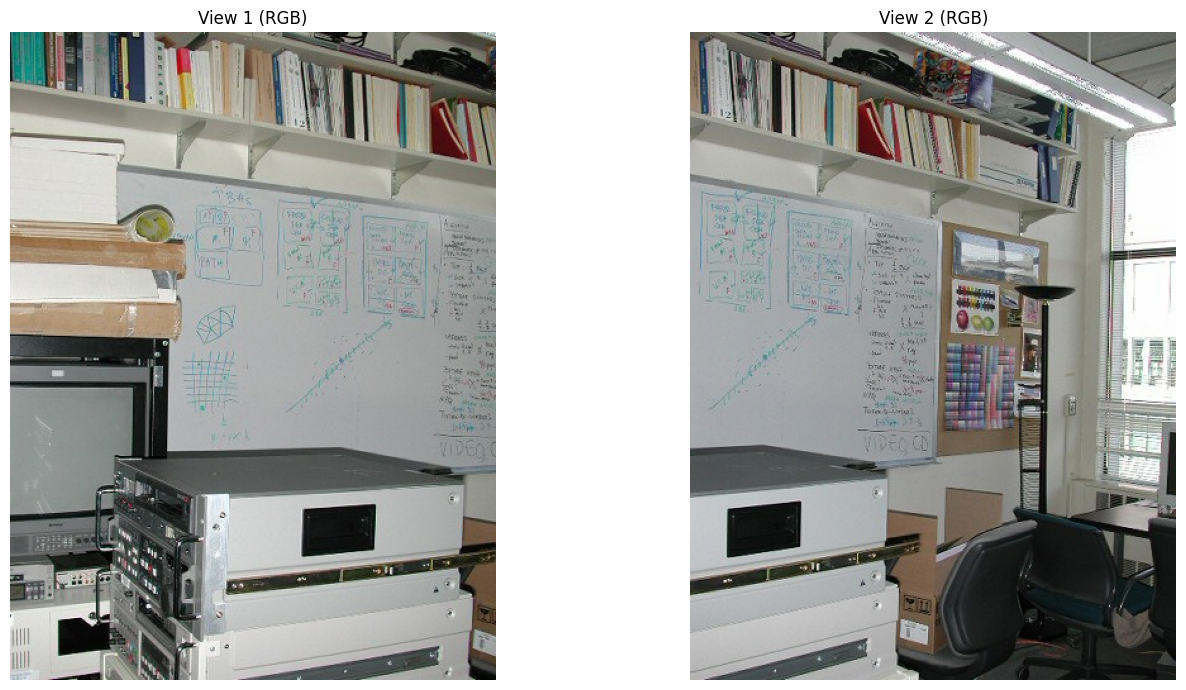

In [132]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].imshow(img1_rgb)
axes[0].set_title("View 1 (RGB)")
axes[0].axis('off')

axes[1].imshow(img2_rgb)
axes[1].set_title("View 2 (RGB)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [133]:
img1_gray = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2GRAY)
img2_gray = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()
kp1_sift = sift.detect(img1_gray, None)
kp2_sift = sift.detect(img2_gray, None)

img1_sift_drawn = cv2.drawKeypoints(img1_rgb, kp1_sift, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
img2_sift_drawn = cv2.drawKeypoints(img2_rgb, kp2_sift, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

In [134]:
print(f"Number of key points with SIFT view1: {len(kp1_sift)}")
print(f"Number of key points with SIFT view2: {len(kp2_sift)}")

Number of key points with SIFT view1: 739
Number of key points with SIFT view2: 839


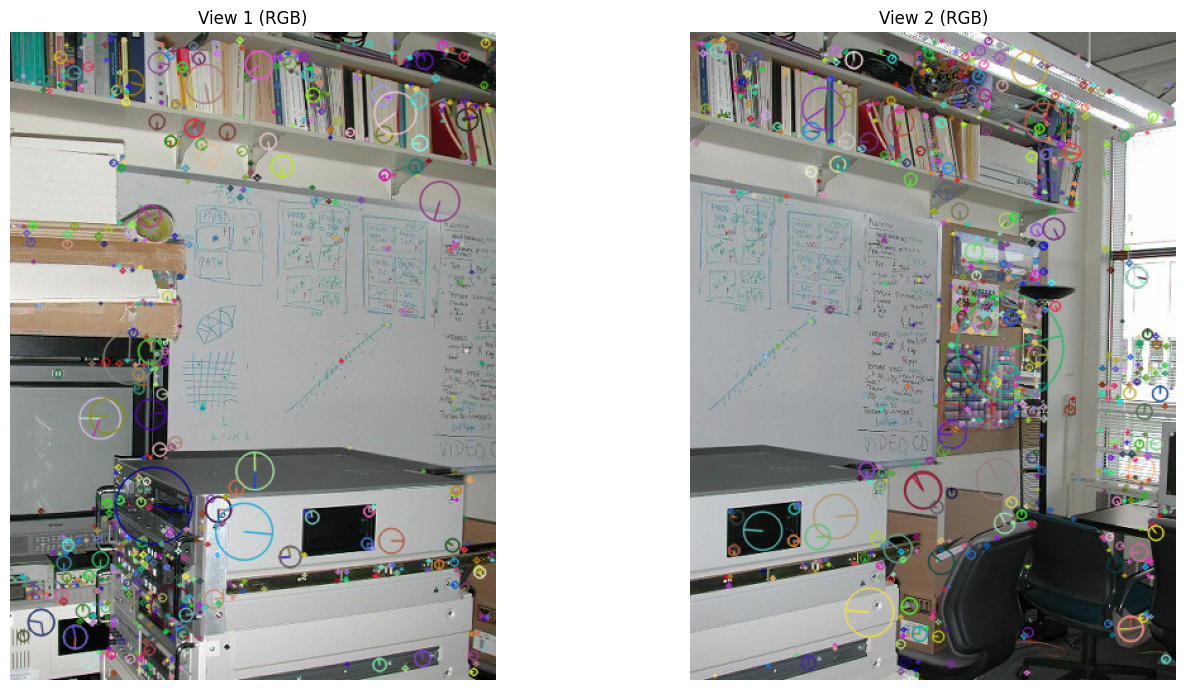

In [135]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].imshow(img1_sift_drawn)
axes[0].set_title("View 1 (RGB)")
axes[0].axis('off')

axes[1].imshow(img2_sift_drawn)
axes[1].set_title("View 2 (RGB)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [136]:
fast = cv2.FastFeatureDetector_create()

kp1_fast = fast.detect(img1_gray, None)
kp2_fast = fast.detect(img2_gray, None)

img1_fast_drawn = cv2.drawKeypoints(img1_rgb, kp1_fast, None, color=(255, 0, 0))
img2_fast_drawn = cv2.drawKeypoints(img2_rgb, kp2_fast, None, color=(255, 0, 0))

In [137]:
print(f"Number of key points with FAST view1: {len(kp1_fast)}")
print(f"Number of key points with FAST view1: {len(kp2_fast)}")

Number of key points with FAST view1: 3963
Number of key points with FAST view1: 4949


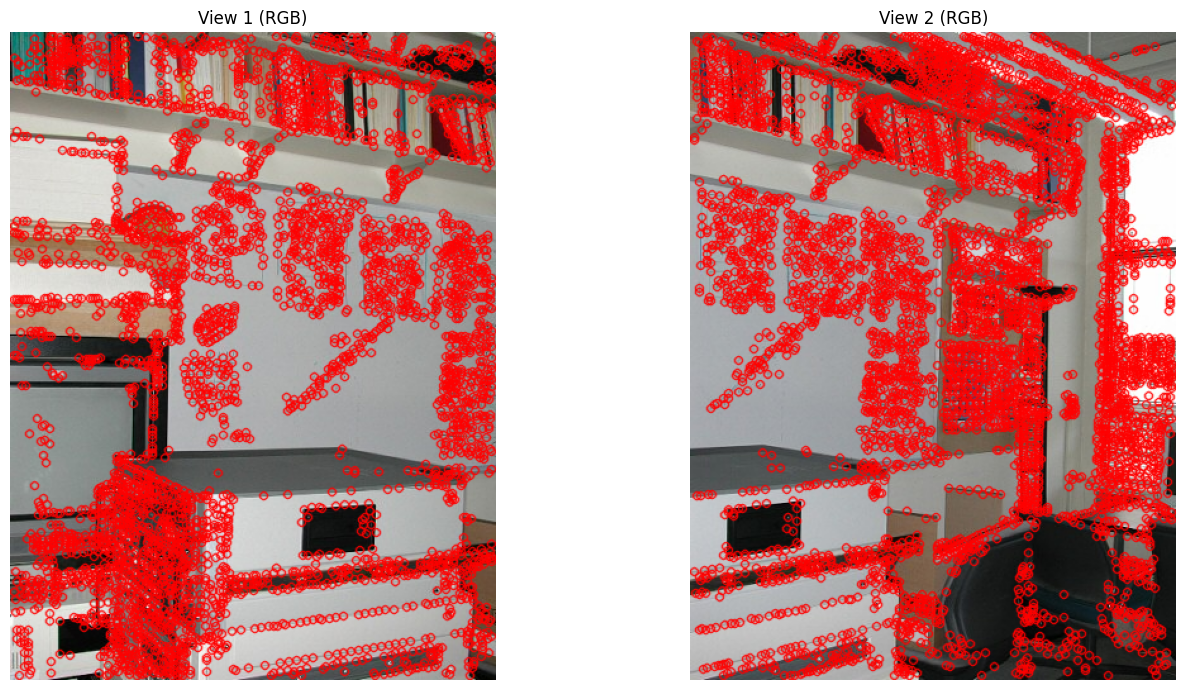

In [138]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].imshow(img1_fast_drawn)
axes[0].set_title("View 1 (RGB)")
axes[0].axis('off')

axes[1].imshow(img2_fast_drawn)
axes[1].set_title("View 2 (RGB)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [139]:
gray1_float = np.float32(img1_gray)
gray2_float = np.float32(img2_gray)

harris_response1 = cv2.cornerHarris(gray1_float, blockSize=2, ksize=3, k=0.04)
harris_response2 = cv2.cornerHarris(gray2_float, blockSize=2, ksize=3, k=0.04)

img1_harris_drawn = img1_rgb.copy()
img2_harris_drawn = img2_rgb.copy()

img1_harris_drawn[harris_response1 > 0.01 * harris_response1.max()] = [255, 0, 0]
img2_harris_drawn[harris_response2 > 0.01 * harris_response2.max()] = [255, 0, 0]

In [140]:
print(f"Number of key points with Harris view1: {np.sum(harris_response1 > 0.01 * harris_response1.max())}")
print(f"Number of key points with Harris view1: {np.sum(harris_response2 > 0.01 * harris_response2.max())}")

Number of key points with Harris view1: 2345
Number of key points with Harris view1: 1880


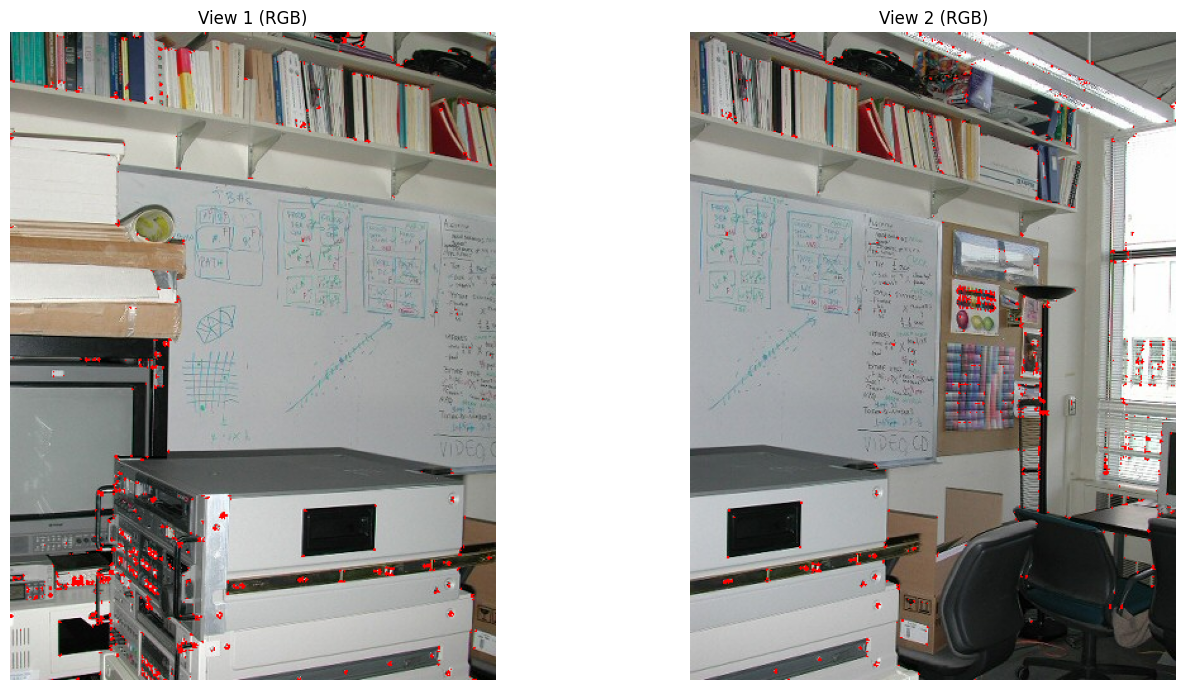

In [141]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].imshow(img1_harris_drawn)
axes[0].set_title("View 1 (RGB)")
axes[0].axis('off')

axes[1].imshow(img2_harris_drawn)
axes[1].set_title("View 2 (RGB)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [142]:
plt.imsave('./Output_Images/Part_1/View1_SIFT.jpg', img1_sift_drawn)
plt.imsave('./Output_Images/Part_1/View2_SIFT.jpg', img2_sift_drawn)
plt.imsave('./Output_Images/Part_1/View1_FAST.jpg', img1_fast_drawn)
plt.imsave('./Output_Images/Part_1/View2_FAST.jpg', img2_fast_drawn)
plt.imsave('./Output_Images/Part_1/View1_Harris.jpg', img1_harris_drawn)
plt.imsave('./Output_Images/Part_1/View2_Harris.jpg', img2_harris_drawn)

In [143]:
kp1_sift, des1 = sift.compute(img1_gray, kp1_sift)
kp2_sift, des2 = sift.compute(img2_gray, kp2_sift)

des1_norm = des1 / np.linalg.norm(des1, axis=1, keepdims=True)
des2_norm = des2 / np.linalg.norm(des2, axis=1, keepdims=True)

similarity_matrix = np.dot(des1_norm, des2_norm.T)

max_idx = np.unravel_index(np.argmax(similarity_matrix), similarity_matrix.shape)
idx1, idx2 = max_idx

max_similarity = similarity_matrix[idx1, idx2]
print(f"Max normalized similarity {max_similarity:.4f}")

Max normalized similarity 0.9986


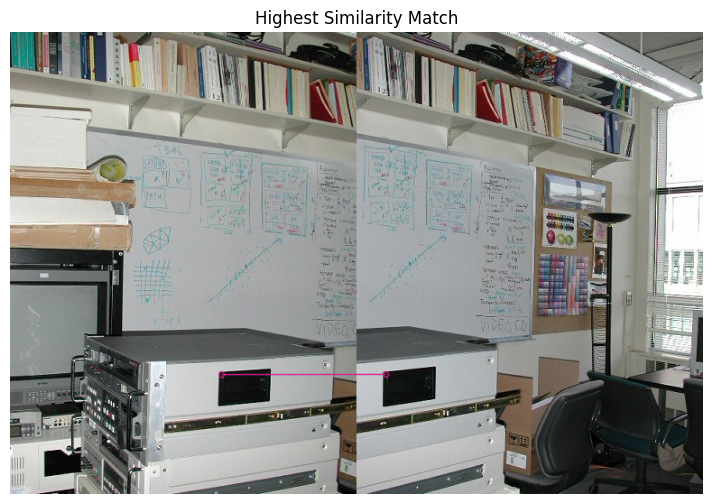

In [144]:
best_match = cv2.DMatch(_queryIdx=idx1, _trainIdx=idx2, _distance=0)

img_best_match = cv2.drawMatches(img1_rgb, kp1_sift, img2_rgb, kp2_sift, [best_match], None, flags=2)

plt.figure(figsize=(12, 6))
plt.imshow(img_best_match)
plt.title("Highest Similarity Match")
plt.axis('off')
plt.show()

In [145]:
plt.imsave('./Output_Images/Part_2/Highest_Similarity_Match.jpg', img_best_match)

In [146]:
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

distance_threshold = 150
good_matches = [m for m in matches if m.distance < distance_threshold]

In [147]:
print(f"Number of good mathces: {len(good_matches)}")

Number of good mathces: 104


In [148]:
img3_matches = cv2.drawMatches(img1_rgb, kp1_sift, img2_rgb, kp2_sift, good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

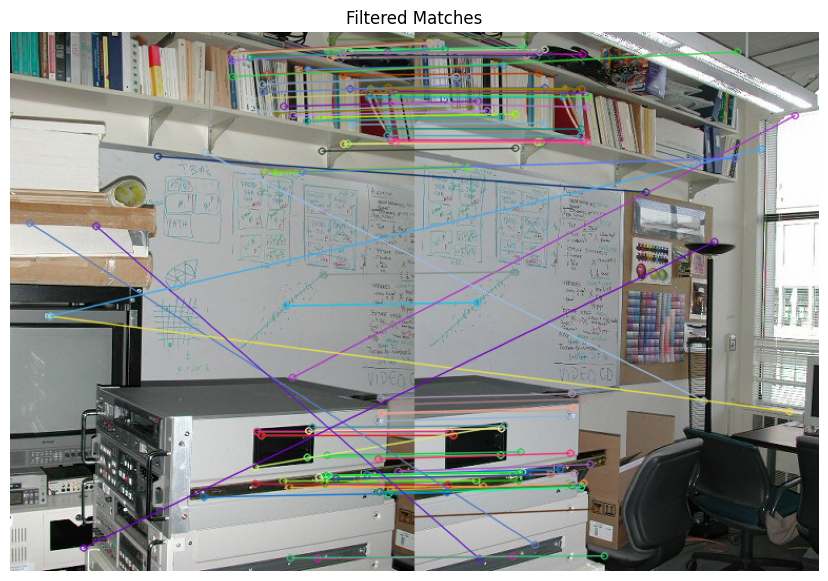

In [149]:
plt.figure(figsize=(15, 7))
plt.imshow(img3_matches)
plt.title("Filtered Matches")
plt.axis('off')
plt.show()

In [150]:
plt.imsave('./Output_Images/Part_3/Matches.jpg', img3_matches)


In [151]:
src_pts = np.float32([kp2_sift[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp1_sift[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)

h1, w1 = img1_rgb.shape[:2]
h2, w2 = img2_rgb.shape[:2]

canvas_width = w1 + w2
canvas_height = max(h1, h2)

img2_warped = cv2.warpPerspective(img2_rgb, H, (canvas_width, canvas_height))

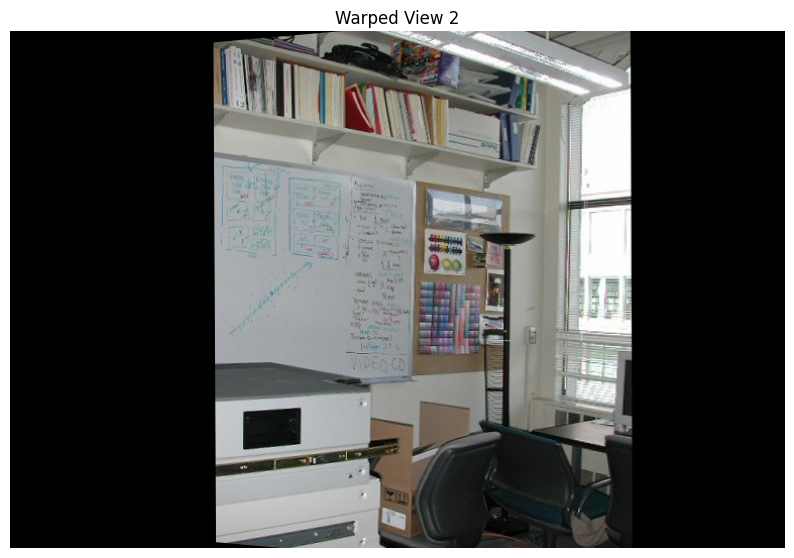

In [152]:
plt.figure(figsize=(10, 8))
plt.imshow(img2_warped)
plt.title("Warped View 2")
plt.axis('off')
plt.show()

In [153]:
plt.imsave('./Output_Images/Part_4/Warped_View2.jpg', img2_warped)

In [154]:
img1_canvas = np.zeros_like(img2_warped)
img1_canvas[0:h1, 0:w1] = img1_rgb

img1_float = img1_canvas.astype(float)
img2_warped_float = img2_warped.astype(float)

mask1 = (img1_float > 0)
mask2 = (img2_warped_float > 0)
overlap = mask1 & mask2

blended_img_float = np.copy(img1_float)
blended_img_float[mask2] = img2_warped_float[mask2] 
blended_img_float[overlap] = (img1_float[overlap] + img2_warped_float[overlap]) / 2.0 

blended_img = np.uint8(blended_img_float)

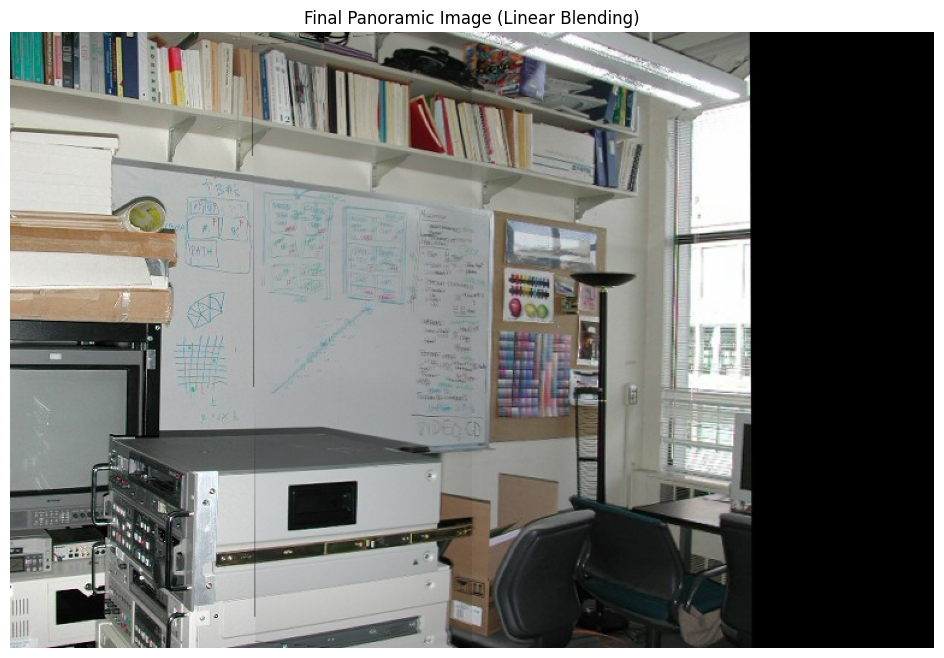

In [155]:
plt.figure(figsize=(12, 8))
plt.imshow(blended_img)
plt.title("Final Panoramic Image (Linear Blending)")
plt.axis('off')
plt.show()

In [156]:
plt.imsave('./Output_Images/Part_5/Final_Panorama.jpg', blended_img)

In [157]:
gray_blended = cv2.cvtColor(blended_img, cv2.COLOR_RGB2GRAY)

_, thresh = cv2.threshold(gray_blended, 0, 255, cv2.THRESH_BINARY)

x, y, w, h = cv2.boundingRect(thresh)

final_cropped_img = blended_img[y:y+h, x:x+w]

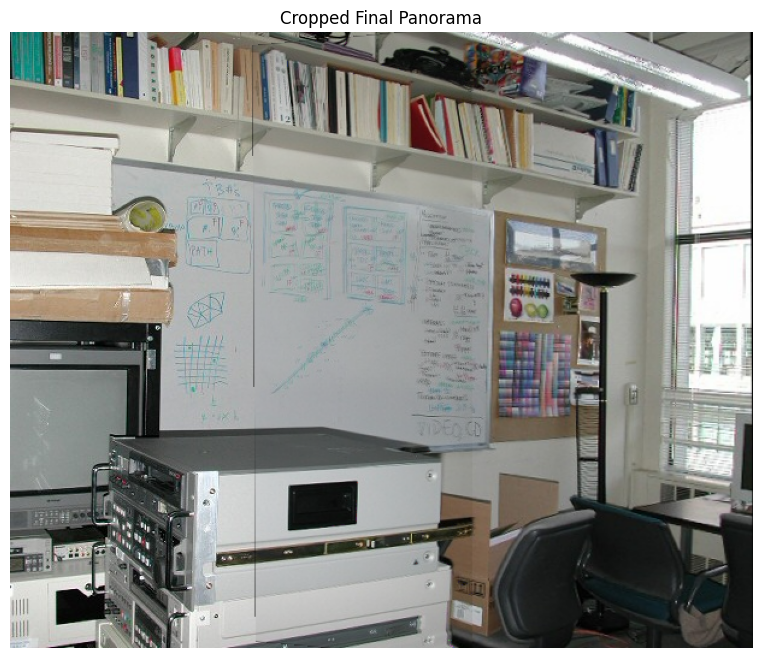

In [158]:
plt.figure(figsize=(15, 8))
plt.imshow(final_cropped_img)
plt.title("Cropped Final Panorama")
plt.axis("off")
plt.show()

plt.imsave('./Output_Images/Part_5/Final_Panorama_Cropped.jpg', final_cropped_img)

### NOW FOR SET2 AND SET3

In [ ]:
def process_image_set(set_name):
    print(f"Processing {set_name}...")
    
    # sakht folder
    output_dirs = [
        f"./Output_Images/{set_name}/Part_1",
        f"./Output_Images/{set_name}/Part_2",
        f"./Output_Images/{set_name}/Part_3",
        f"./Output_Images/{set_name}/Part_4",
        f"./Output_Images/{set_name}/Part_5"
    ]
    for d in output_dirs:
        os.makedirs(d, exist_ok=True)

    # khondan aksa
    img1_path = f"./Input_Images/{set_name}/View1.jpg"
    img2_path = f"./Input_Images/{set_name}/View2.jpg"
    
    img1_bgr = cv2.imread(img1_path)
    img2_bgr = cv2.imread(img2_path)

    # check aks
    if img1_bgr is None or img2_bgr is None:
        print("aks peyda nashod!")
        return

    # tabdil rang
    img1_rgb = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2RGB)
    img2_rgb = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2RGB)
    img1_gray = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2GRAY)
    img2_gray = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2GRAY)

    # SIFT
    sift = cv2.SIFT_create()
    kp1_sift = sift.detect(img1_gray, None)
    kp2_sift = sift.detect(img2_gray, None)
    img1_sift_drawn = cv2.drawKeypoints(img1_rgb, kp1_sift, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    img2_sift_drawn = cv2.drawKeypoints(img2_rgb, kp2_sift, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    # FAST
    fast = cv2.FastFeatureDetector_create()
    kp1_fast = fast.detect(img1_gray, None)
    kp2_fast = fast.detect(img2_gray, None)
    img1_fast_drawn = cv2.drawKeypoints(img1_rgb, kp1_fast, None, color=(255, 0, 0))
    img2_fast_drawn = cv2.drawKeypoints(img2_rgb, kp2_fast, None, color=(255, 0, 0))

    # Harris
    gray1_float = np.float32(img1_gray)
    gray2_float = np.float32(img2_gray)
    harris_response1 = cv2.cornerHarris(gray1_float, blockSize=2, ksize=3, k=0.04)
    harris_response2 = cv2.cornerHarris(gray2_float, blockSize=2, ksize=3, k=0.04)
    img1_harris_drawn = img1_rgb.copy()
    img2_harris_drawn = img2_rgb.copy()
    img1_harris_drawn[harris_response1 > 0.01 * harris_response1.max()] = [255, 0, 0]
    img2_harris_drawn[harris_response2 > 0.01 * harris_response2.max()] = [255, 0, 0]
    
    # zakhire part 1
    plt.imsave(f"./Output_Images/{set_name}/Part_1/View1_SIFT.jpg", img1_sift_drawn)
    plt.imsave(f"./Output_Images/{set_name}/Part_1/View2_SIFT.jpg", img2_sift_drawn)
    plt.imsave(f"./Output_Images/{set_name}/Part_1/View1_FAST.jpg", img1_fast_drawn)
    plt.imsave(f"./Output_Images/{set_name}/Part_1/View2_FAST.jpg", img2_fast_drawn)
    plt.imsave(f"./Output_Images/{set_name}/Part_1/View1_Harris.jpg", img1_harris_drawn)
    plt.imsave(f"./Output_Images/{set_name}/Part_1/View2_Harris.jpg", img2_harris_drawn)

    # mohasebe shabahat
    kp1_sift, des1 = sift.compute(img1_gray, kp1_sift)
    kp2_sift, des2 = sift.compute(img2_gray, kp2_sift)
    des1_norm = des1 / np.linalg.norm(des1, axis=1, keepdims=True)
    des2_norm = des2 / np.linalg.norm(des2, axis=1, keepdims=True)
    
    similarity_matrix = np.dot(des1_norm, des2_norm.T)
    max_idx = np.unravel_index(np.argmax(similarity_matrix), similarity_matrix.shape)
    idx1, idx2 = max_idx
    best_match = cv2.DMatch(_queryIdx=idx1, _trainIdx=idx2, _distance=0)
    
    img_best_match = cv2.drawMatches(img1_rgb, kp1_sift, img2_rgb, kp2_sift, [best_match], None, flags=2)
    plt.imsave(f"./Output_Images/{set_name}/Part_2/Highest_Similarity_Match.jpg", img_best_match)

    # peyda kardan match ha
    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)
    good_matches = [m for m in matches if m.distance < 150]
    
    img3_matches = cv2.drawMatches(img1_rgb, kp1_sift, img2_rgb, kp2_sift, good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    plt.imsave(f"./Output_Images/{set_name}/Part_3/Matches.jpg", img3_matches)

    # homography 
    src_pts = np.float32([kp2_sift[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp1_sift[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    H, _ = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    # mohasebe ab'ad o shift (baraye jologiri az boresh)
    h1, w1 = img1_rgb.shape[:2]
    h2, w2 = img2_rgb.shape[:2]
    
    corners1 = np.float32([[0, 0], [0, h1], [w1, h1], [w1, 0]]).reshape(-1, 1, 2)
    corners2 = np.float32([[0, 0], [0, h2], [w2, h2], [w2, 0]]).reshape(-1, 1, 2)
    
    corners2_warped = cv2.perspectiveTransform(corners2, H)
    all_corners = np.concatenate((corners1, corners2_warped), axis=0)
    
    [xmin, ymin] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    [xmax, ymax] = np.int32(all_corners.max(axis=0).ravel() + 0.5)
    
    # matris shift (Translation)
    t = [-xmin, -ymin]
    Ht = np.array([[1, 0, t[0]], [0, 1, t[1]], [0, 0, 1]]) 
    
    canvas_w = xmax - xmin
    canvas_h = ymax - ymin
    
    # warp ba matris jadid
    img2_warped = cv2.warpPerspective(img2_rgb, Ht.dot(H), (canvas_w, canvas_h))
    plt.imsave(f"./Output_Images/{set_name}/Part_4/Warped_View2.jpg", img2_warped)

    # tarkib kardan
    img1_canvas = np.zeros_like(img2_warped)
    img1_canvas[t[1]:h1+t[1], t[0]:w1+t[0]] = img1_rgb

    img1_float = img1_canvas.astype(float)
    img2_warped_float = img2_warped.astype(float)

    mask1 = (img1_float > 0)
    mask2 = (img2_warped_float > 0)
    overlap = mask1 & mask2

    blended_img_float = np.copy(img1_float)
    blended_img_float[mask2] = img2_warped_float[mask2]
    blended_img_float[overlap] = (img1_float[overlap] + img2_warped_float[overlap]) / 2.0
    blended_img = np.uint8(blended_img_float)

    # boresh siyahia
    gray_blended = cv2.cvtColor(blended_img, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray_blended, 0, 255, cv2.THRESH_BINARY)
    x, y, w, h = cv2.boundingRect(thresh)
    final_cropped_img = blended_img[y:y+h, x:x+w]

    # zakhire nahayi
    plt.imsave(f"./Output_Images/{set_name}/Part_5/Final_Panorama.jpg", final_cropped_img)
    print(f"Done {set_name}!\n")

# ejra baray harkodoom as set ha besoorat joda
sets_to_process = ["Set1", "Set2", "Set3"]
for s in sets_to_process:
    process_image_set(s)

Processing Set1...


Done Set1!

Processing Set2...
Done Set2!

Processing Set3...
Done Set3!

